In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import math
import solvers
import sde
import dnnlib

torch.manual_seed(42)

In [26]:
with dnnlib.util.open_url("model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [27]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [28]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [29]:
labels = torch.zeros((16, 1000)).to("cuda")
for i in range(16):
    labels[i, i] = 1

In [30]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde.EDMSDE().to("cuda")
# sde_ = sde.VarianceExplodingEDMSDE(sigma_min, sigma_max).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")
rsde.ode = False

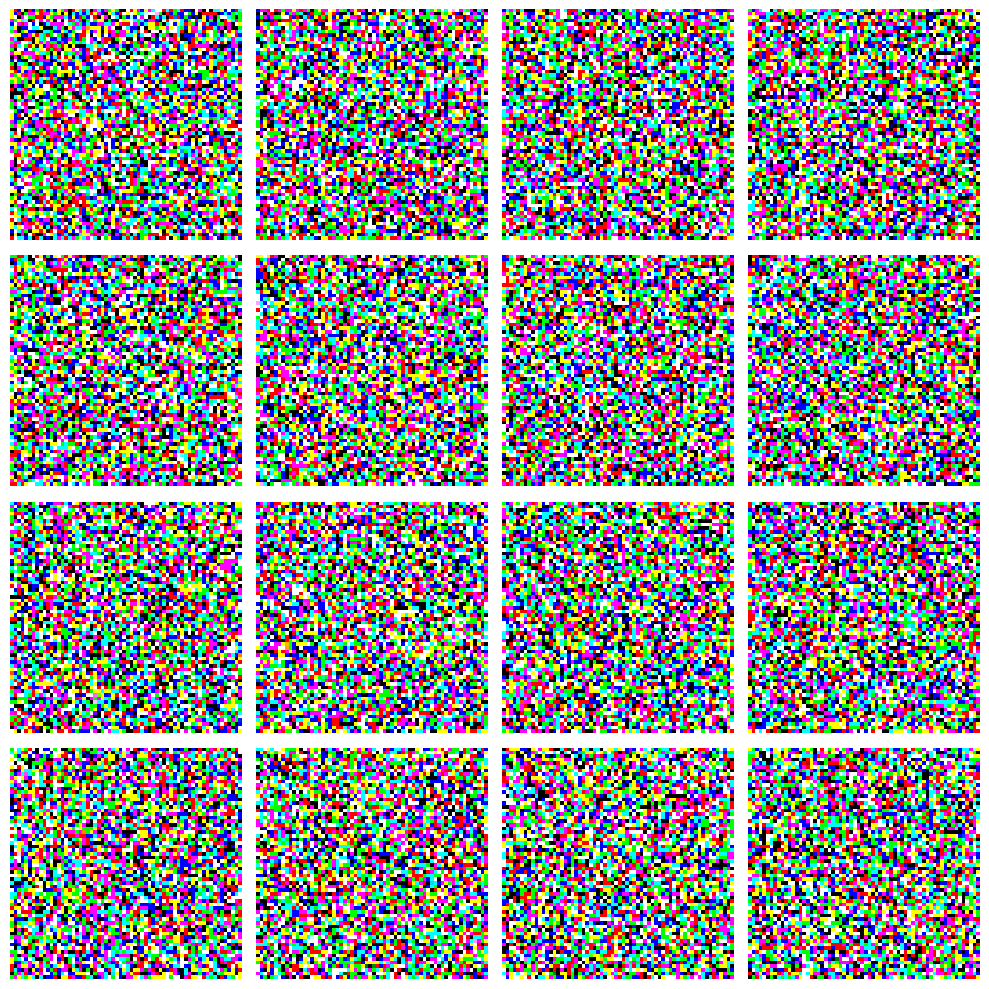

In [31]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [33]:
n_steps = 72
rho = 7
# From EDM2 code
step_indices = torch.arange(n_steps)
sigma_steps = (sigma_max ** (1 / rho) + step_indices / (n_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
discretisation = torch.cat([sigma_steps, torch.zeros_like(sigma_steps[:1])])
# discretisation = torch.linspace(1, 0, n_steps)

In [34]:
em_solver = solvers.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

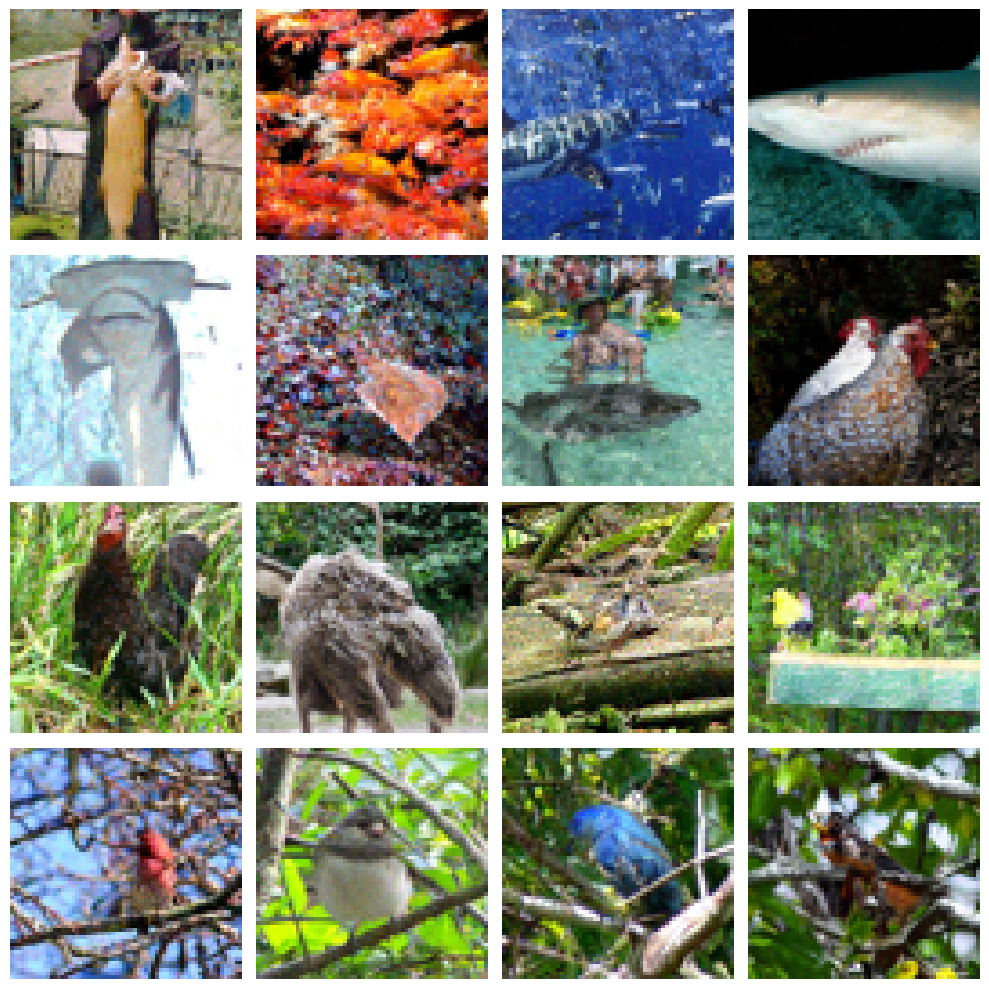

In [10]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [11]:
sigmas = []
def pi_callback(x, t):    
    print(f"sigma = {torch.mean(t)}")
    sigmas.append(torch.mean(t))

In [45]:
sigmas = []

rsde.reset_nfe()

pi_solver = solvers.PISolver(
    rsde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.3,
    tau_r=1.5,
    alpha=0.9,
    h_start=3,
    max_decrease=0.2,
    max_increase=5,
    interval=(80, 0.002),
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 77.0
sigma = 72.03689575195312
sigma = 67.15547180175781
sigma = 62.088279724121094
sigma = 57.148597717285156
sigma = 52.410621643066406
sigma = 47.96125030517578
sigma = 43.81509780883789
sigma = 39.986915588378906
sigma = 36.467994689941406
sigma = 33.23893737792969
sigma = 30.287736892700195
sigma = 27.59195327758789
sigma = 25.130016326904297
sigma = 22.88512420654297
sigma = 20.838041305541992
sigma = 18.973037719726562
sigma = 17.274925231933594
sigma = 15.725565910339355
sigma = 14.314987182617188
sigma = 13.028945922851562
sigma = 11.857715606689453
sigma = 10.791839599609375
sigma = 9.819862365722656
sigma = 8.935077667236328
sigma = 8.128374099731445
sigma = 7.392925262451172
sigma = 6.7224884033203125
sigma = 6.111337661743164
sigma = 5.553955554962158
sigma = 5.04676628112793
sigma = 4.584324836730957
sigma = 4.163613796234131
sigma = 3.7799341678619385
sigma = 3.4306440353393555
sigma = 3.1118454933166504
sigma = 2.8215246200561523
sigma = 2.557016134262085
sigma 

In [46]:
rsde.nfe / 16

132.0

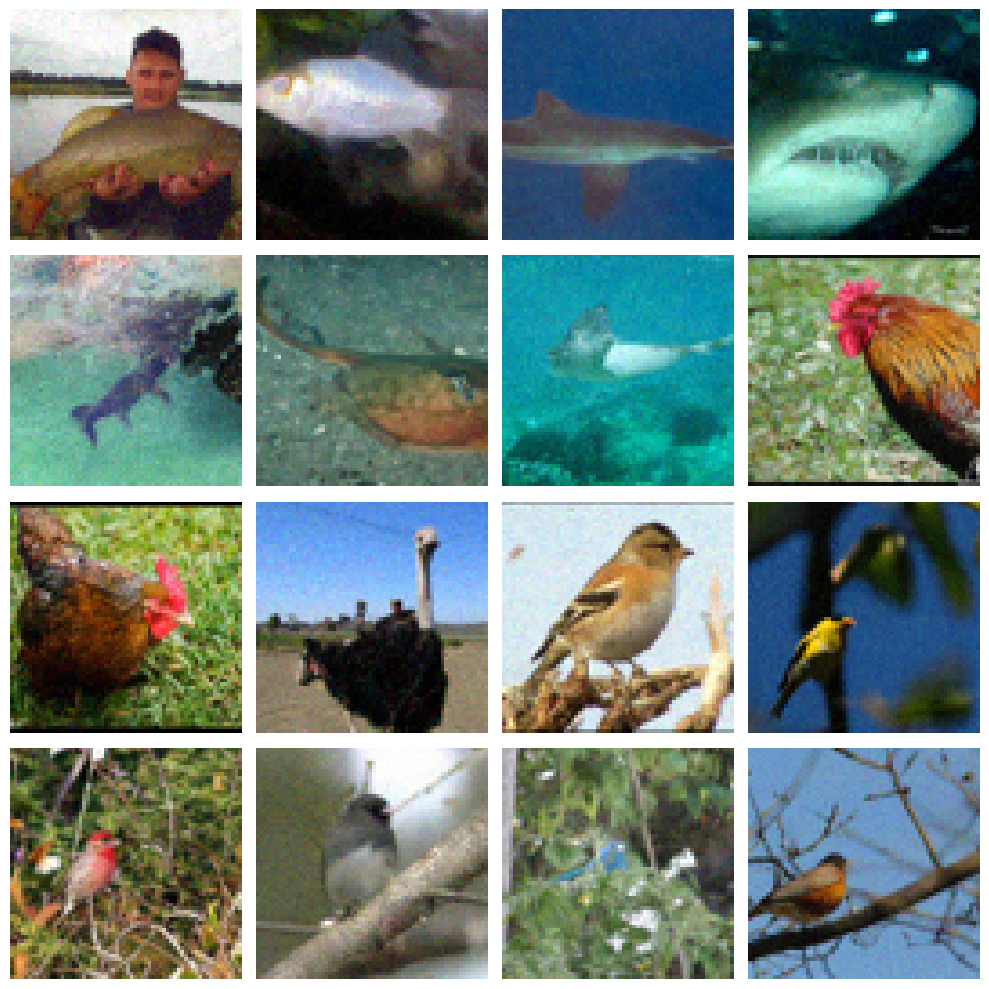

In [47]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

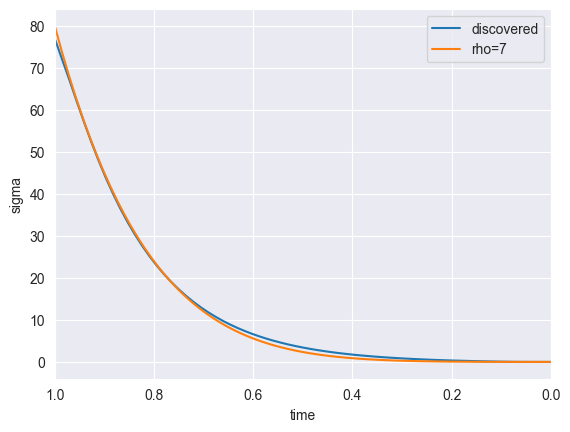

In [51]:
plt.plot(torch.linspace(1, 0, len(sigmas)), [sigma.cpu() for sigma in sigmas], label="discovered")
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")